# Flood Risk Prediction Model
**Dataset:** Kaggle Playground Series S4E5  
**Target:** `FloodProbability` (regression)

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_csv("../data/flood/train.csv")
df_test  = pd.read_csv("../data/flood/test.csv")

print(f"Train shape : {df_train.shape}")
print(f"Test shape  : {df_test.shape}")
df_train.head()

Train shape : (1117957, 22)
Test shape  : (745305, 21)


,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


## 2. Exploratory Data Analysis (EDA)

In [2]:
# Descriptive statistics
df_train.describe()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,5.589780e+05,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,3.227265e+05,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,2.794890e+05,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.589780e+05,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,8.384670e+05,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.117956e+06,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


In [3]:
# Check missing values and data types
print("Missing values:", df_train.isnull().sum().sum())
print()
df_train.info()

Missing values: 0

<class 'pandas.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 n

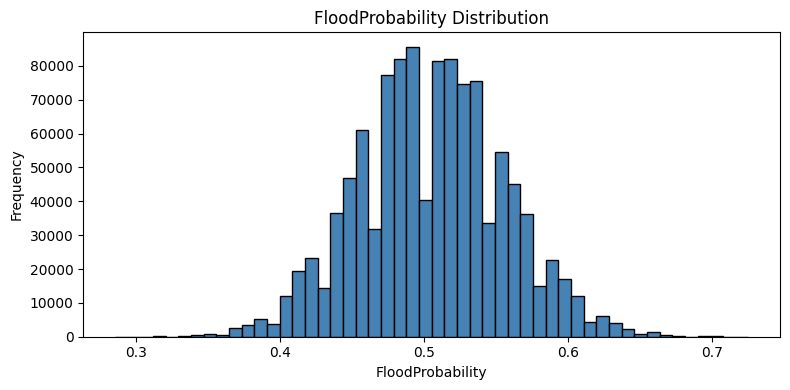

count    1.117957e+06
mean     5.044803e-01
std      5.102610e-02
min      2.850000e-01
25%      4.700000e-01
50%      5.050000e-01
75%      5.400000e-01
max      7.250000e-01
Name: FloodProbability, dtype: float64


In [4]:
# Target distribution
plt.figure(figsize=(8, 4))
plt.hist(df_train['FloodProbability'], bins=50, edgecolor='black', color='steelblue')
plt.title('FloodProbability Distribution')
plt.xlabel('FloodProbability')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print(df_train['FloodProbability'].describe())

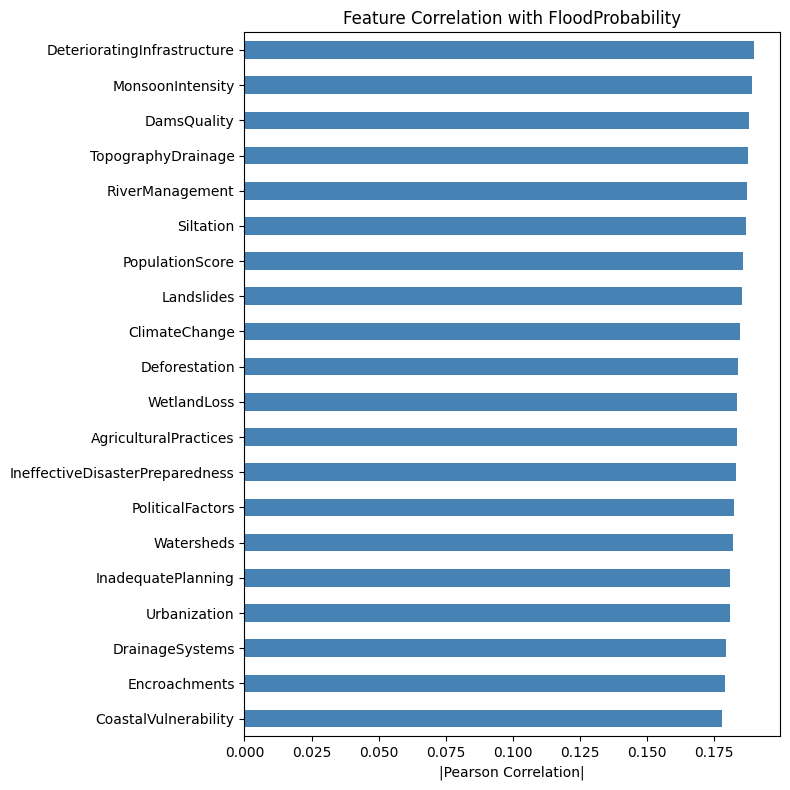

In [5]:
# Feature correlation with target
feature_cols = [c for c in df_train.columns if c not in ['id', 'FloodProbability']]

corr = df_train[feature_cols + ['FloodProbability']].corr()['FloodProbability'].drop('FloodProbability')
corr_sorted = corr.abs().sort_values(ascending=True)

plt.figure(figsize=(8, 8))
corr_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with FloodProbability')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()

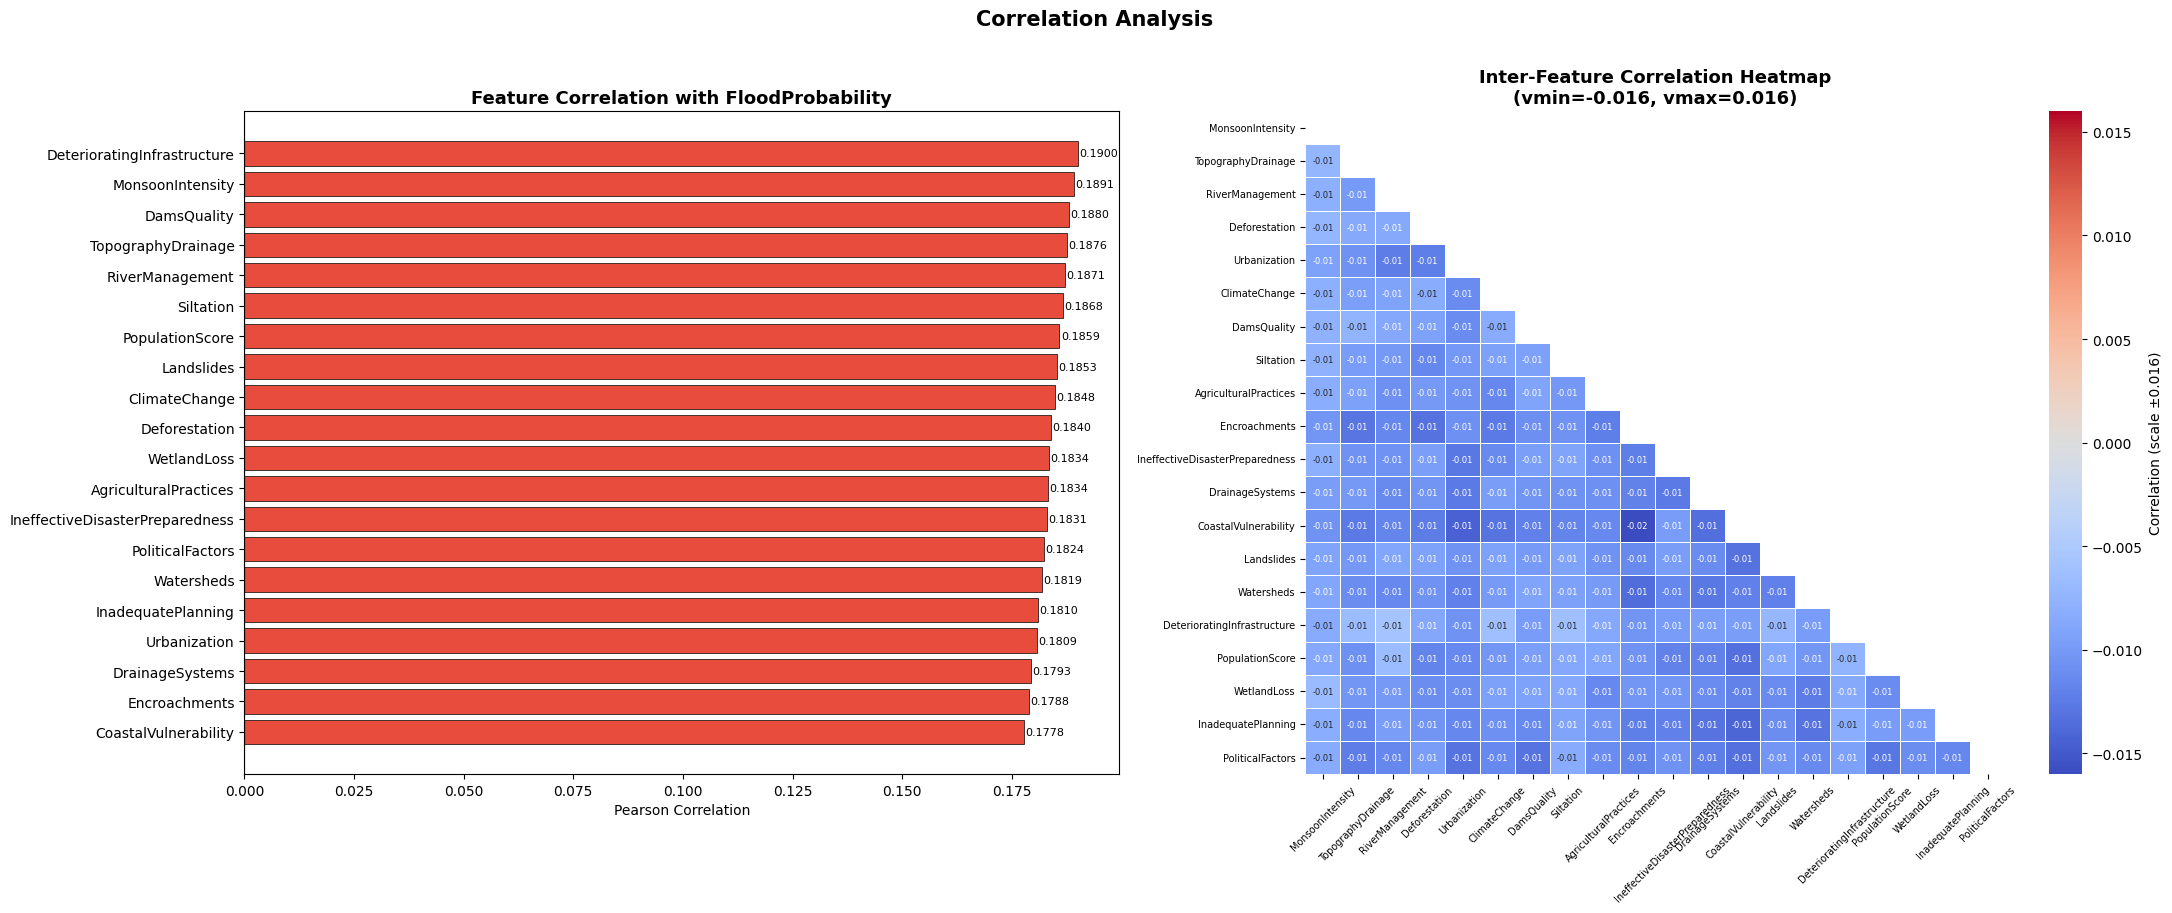

Max inter-feature correlation: 0.0160
All features are nearly independent (synthetic dataset).
Feature-target correlation range: 0.1778 to 0.1900


In [6]:
# Correlation analysis
# Synthetic features are nearly independent of each other.
# Two plots: feature-target correlation bar chart + inter-feature heatmap with adjusted scale.

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# --- Plot 1: Feature correlation with FloodProbability ---
corr_target = df_train[feature_cols + ["FloodProbability"]].corr()["FloodProbability"].drop("FloodProbability")
corr_target_sorted = corr_target.sort_values()

colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_target_sorted]
axes[0].barh(corr_target_sorted.index, corr_target_sorted.values, color=colors, edgecolor="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Feature Correlation with FloodProbability", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Pearson Correlation")
for i_bar, (val, name) in enumerate(zip(corr_target_sorted.values, corr_target_sorted.index)):
    offset = 0.0003 if val >= 0 else -0.0003
    ha = "left" if val >= 0 else "right"
    axes[0].text(val + offset, i_bar, f"{val:.4f}", va="center", ha=ha, fontsize=8)

# --- Plot 2: Inter-feature heatmap with adaptive scale ---
corr_matrix = df_train[feature_cols].corr()
vmax = round(corr_matrix[corr_matrix < 1].abs().max().max(), 3)

sns.heatmap(
    corr_matrix, mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
    annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.4, vmin=-vmax, vmax=vmax,
    annot_kws={"size": 6}, ax=axes[1],
    cbar_kws={"label": f"Correlation (scale \u00b1{vmax})"}
)
axes[1].set_title(f"Inter-Feature Correlation Heatmap\n(vmin=-{vmax}, vmax={vmax})", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", rotation=0, labelsize=7)

plt.suptitle("Correlation Analysis", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Max inter-feature correlation: {vmax:.4f}")
print("All features are nearly independent (synthetic dataset).")
print(f"Feature-target correlation range: {corr_target.min():.4f} to {corr_target.max():.4f}")

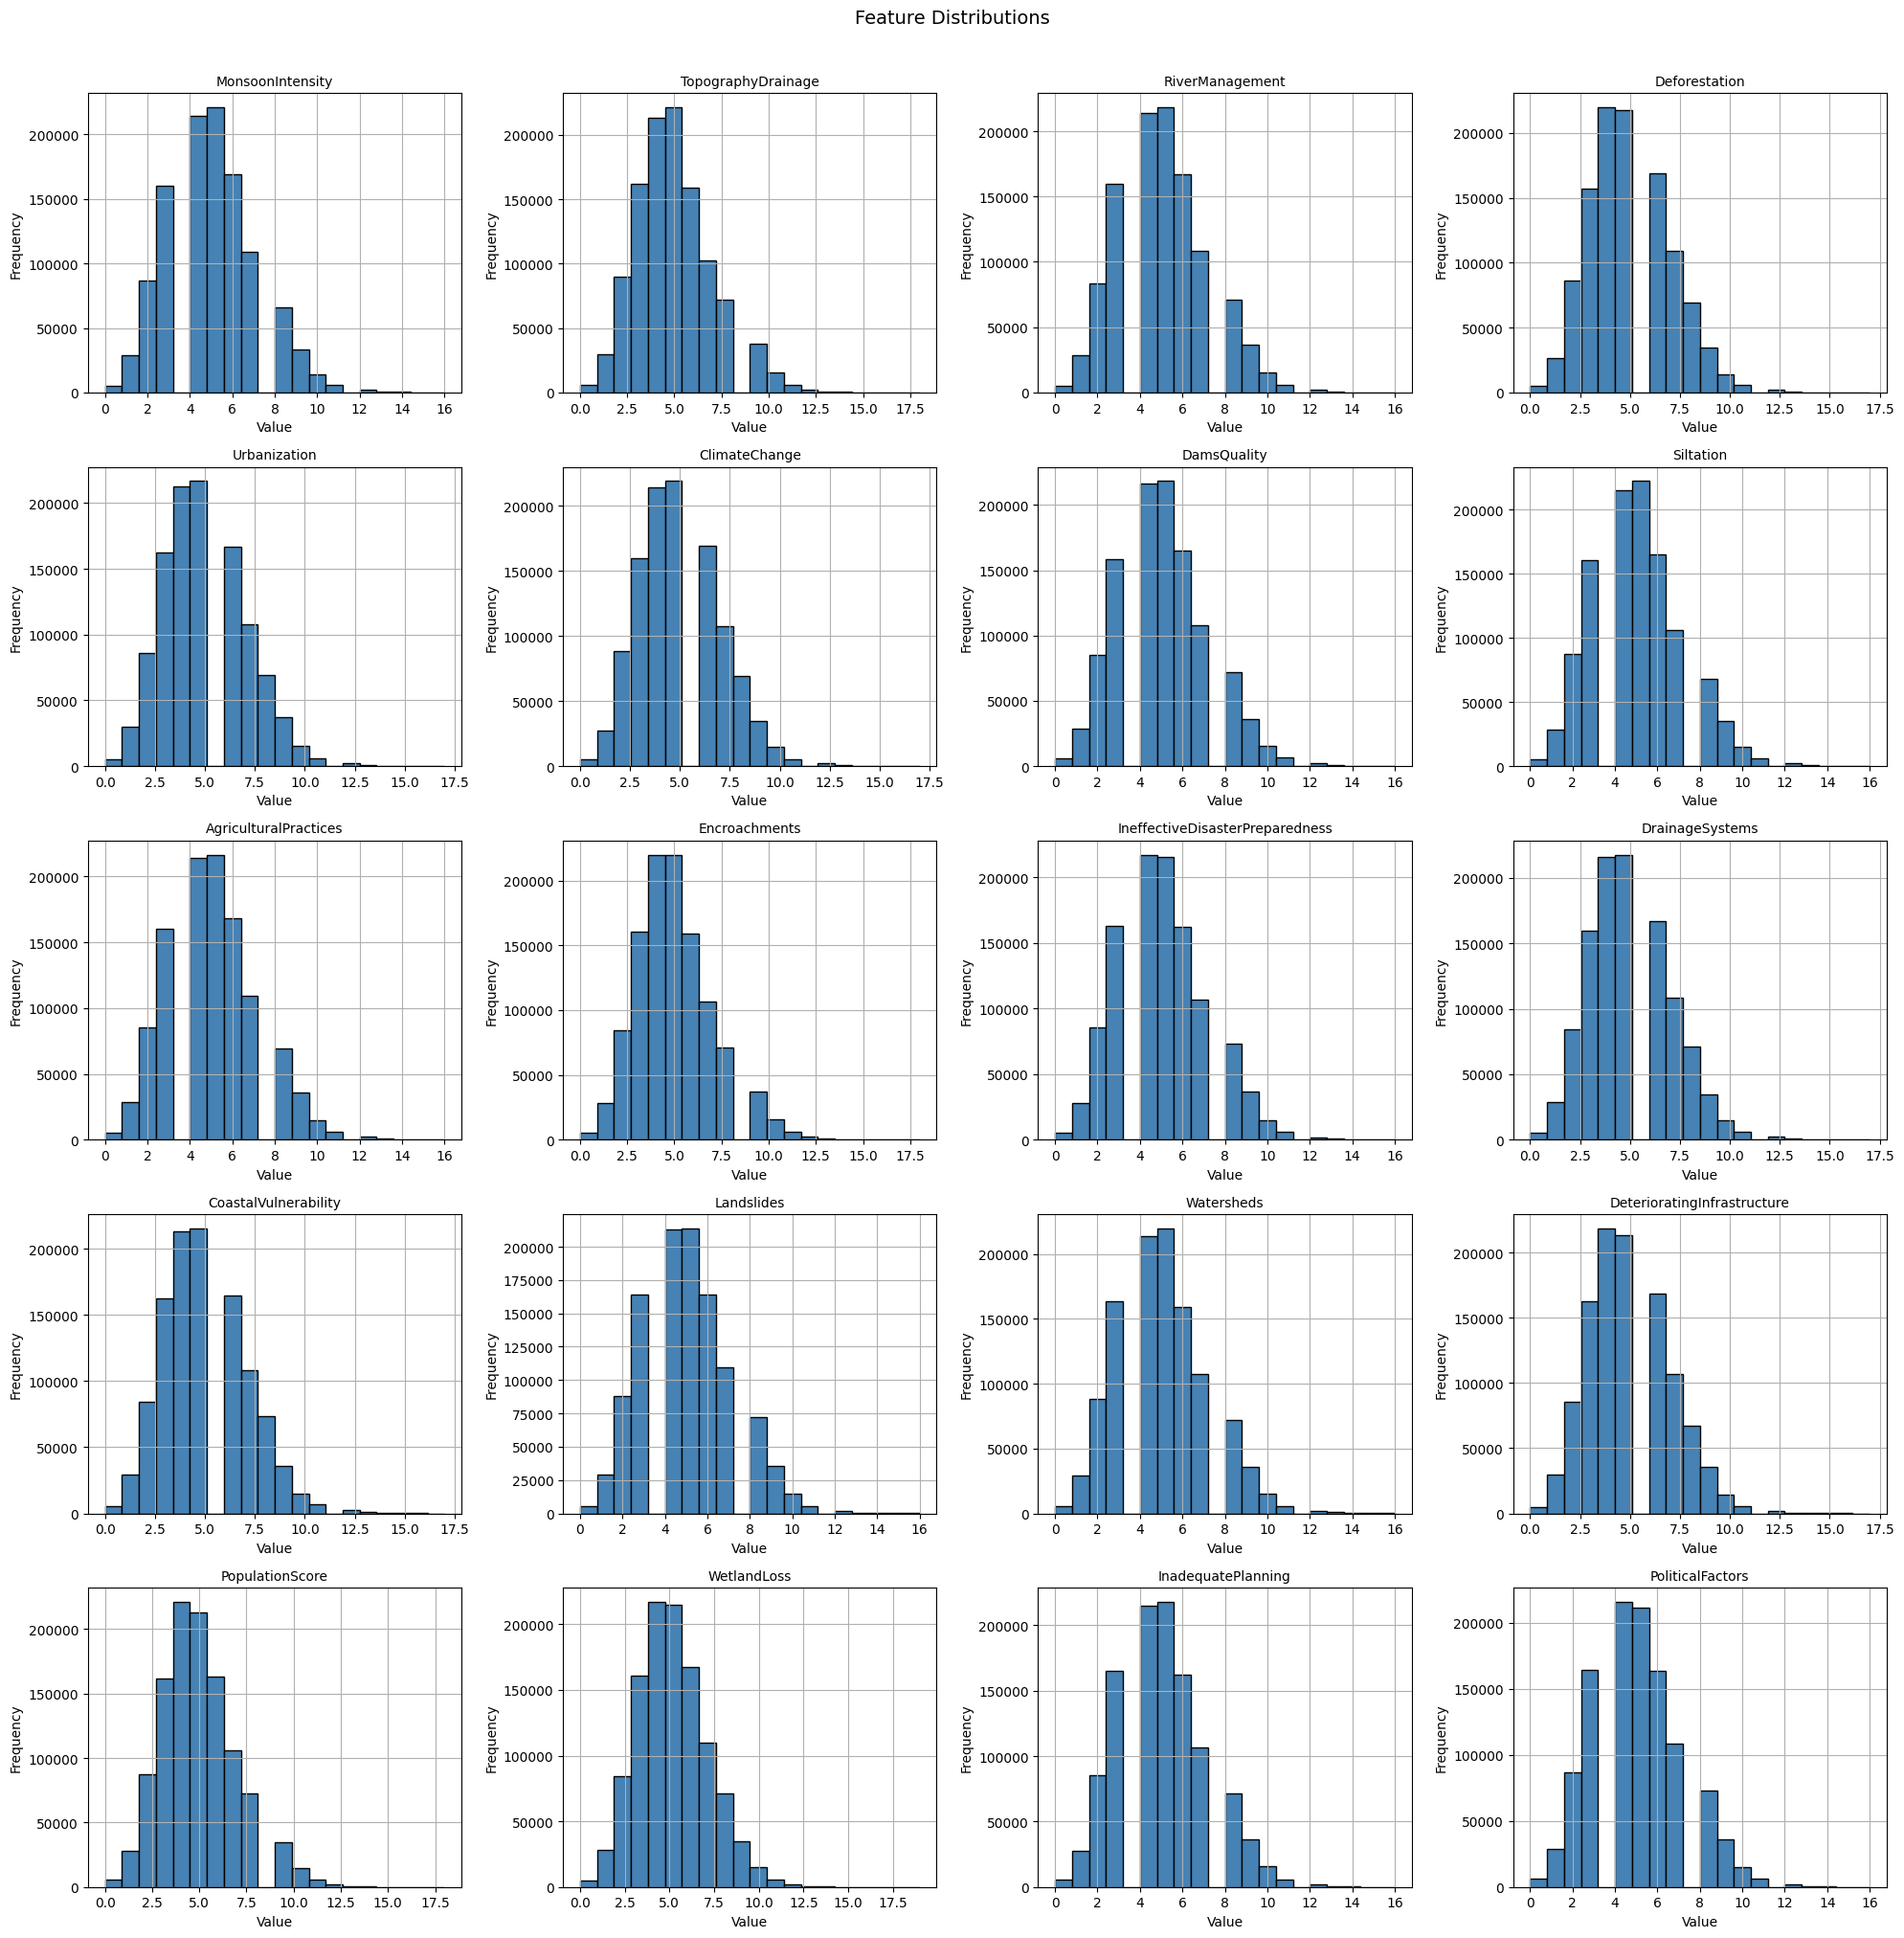

In [7]:
# Feature distributions
n_cols = 4
n_rows = -(-len(feature_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    df_train[col].hist(ax=axes[i], bins=20, edgecolor='black', color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

This is a synthetic dataset — `FloodProbability` is generated from a linear combination of all features.
Adding the **sum of all risk factors** as a new feature consistently improves model performance.

In [8]:
feature_cols = [c for c in df_train.columns if c not in ['id', 'FloodProbability']]

# New feature: sum of all risk factor scores
df_train['total_risk'] = df_train[feature_cols].sum(axis=1)
df_test['total_risk']  = df_test[feature_cols].sum(axis=1)

# Update feature list
all_features = feature_cols + ['total_risk']

print(f"Total features : {len(all_features)}")
print(f"Correlation of total_risk with FloodProbability: {df_train['total_risk'].corr(df_train['FloodProbability']):.4f}")

Total features : 21
Correlation of total_risk with FloodProbability: 0.9192


## 4. Train-Validation Split

> **Note:** No outlier removal applied — the dataset is synthetic and tree-based models are inherently robust to outliers.
> Feature scaling is also unnecessary since gradient boosting operates on rank/thresholds, not raw magnitudes.

In [9]:
from sklearn.model_selection import train_test_split

X = df_train[all_features]
y = df_train['FloodProbability']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total samples      : {len(X):,}")
print(f"Training samples   : {len(X_train):,}")
print(f"Validation samples : {len(X_val):,}")

Total samples      : 1,117,957
Training samples   : 894,365
Validation samples : 223,592


## 5. Modeling

### 5.1 Linear Regression (Baseline)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_val)

mae_lr = mean_absolute_error(y_val, pred_lr)
mse_lr = mean_squared_error(y_val, pred_lr)
r2_lr  = r2_score(y_val, pred_lr)

print("Linear Regression")
print(f"  MAE : {mae_lr:.6f}")
print(f"  MSE : {mse_lr:.6f}")
print(f"  R2  : {r2_lr:.6f}")

df_results = pd.DataFrame(
    {'MAE': [mae_lr], 'MSE': [mse_lr], 'R2': [r2_lr]},
    index=['Linear Regression']
)
df_results

Linear Regression
  MAE : 0.015792
  MSE : 0.000403
  R2  : 0.844877


,MAE,MSE,R2
Linear Regression,0.015792,0.000403,0.844877


### 5.2 LightGBM (Primary Model)

In [11]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

pred_lgbm = lgbm.predict(X_val)

mae_lgbm = mean_absolute_error(y_val, pred_lgbm)
mse_lgbm = mean_squared_error(y_val, pred_lgbm)
r2_lgbm  = r2_score(y_val, pred_lgbm)

print("\nLightGBM")
print(f"  MAE : {mae_lgbm:.6f}")
print(f"  MSE : {mse_lgbm:.6f}")
print(f"  R2  : {r2_lgbm:.6f}")

df_results.loc['LightGBM'] = [mae_lgbm, mse_lgbm, r2_lgbm]
df_results

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.000347141
[200]	valid_0's l2: 0.000345719
[300]	valid_0's l2: 0.000345328
[400]	valid_0's l2: 0.000345211
[500]	valid_0's l2: 0.000345138
[600]	valid_0's l2: 0.000345101
[700]	valid_0's l2: 0.000345067
[800]	valid_0's l2: 0.000345027
[900]	valid_0's l2: 0.000344974
Early stopping, best iteration is:
[904]	valid_0's l2: 0.00034497

LightGBM
  MAE : 0.014461
  MSE : 0.000345
  R2  : 0.867282


,MAE,MSE,R2
Linear Regression,0.015792,0.000403,0.844877
LightGBM,0.014461,0.000345,0.867282


### 5.3 XGBoost

In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    early_stopping_rounds=50
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

pred_xgb = xgb.predict(X_val)

mae_xgb = mean_absolute_error(y_val, pred_xgb)
mse_xgb = mean_squared_error(y_val, pred_xgb)
r2_xgb  = r2_score(y_val, pred_xgb)

print("\nXGBoost")
print(f"  MAE : {mae_xgb:.6f}")
print(f"  MSE : {mse_xgb:.6f}")
print(f"  R2  : {r2_xgb:.6f}")

df_results.loc['XGBoost'] = [mae_xgb, mse_xgb, r2_xgb]
df_results

[0]	validation_0-rmse:0.04879
[100]	validation_0-rmse:0.01867
[200]	validation_0-rmse:0.01862
[300]	validation_0-rmse:0.01861
[400]	validation_0-rmse:0.01860
[500]	validation_0-rmse:0.01860
[600]	validation_0-rmse:0.01859
[700]	validation_0-rmse:0.01859
[800]	validation_0-rmse:0.01859
[900]	validation_0-rmse:0.01859
[1000]	validation_0-rmse:0.01859
[1100]	validation_0-rmse:0.01858
[1200]	validation_0-rmse:0.01858
[1227]	validation_0-rmse:0.01858

XGBoost
  MAE : 0.014464
  MSE : 0.000345
  R2  : 0.867136


,MAE,MSE,R2
Linear Regression,0.015792,0.000403,0.844877
LightGBM,0.014461,0.000345,0.867282
XGBoost,0.014464,0.000345,0.867136


## 6. Model Comparison

Model Comparison
                        MAE       MSE        R2
LightGBM           0.014461  0.000345  0.867282
XGBoost            0.014464  0.000345  0.867136
Linear Regression  0.015792  0.000403  0.844877


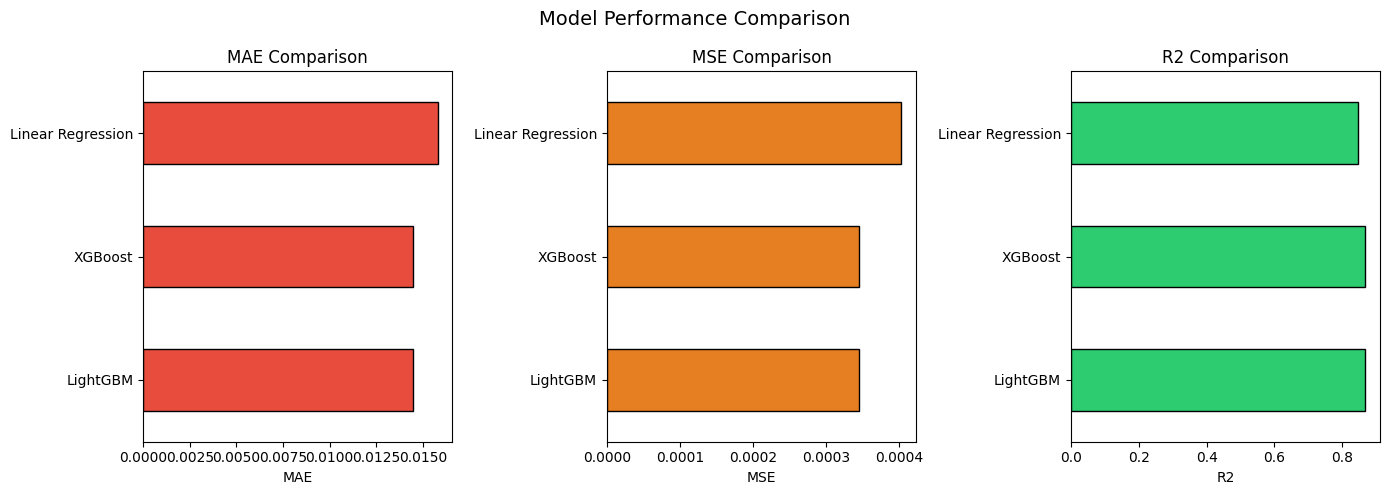

In [13]:
print("=" * 50)
print("Model Comparison")
print("=" * 50)
print(df_results.sort_values('R2', ascending=False).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'MSE', 'R2']
colors = ['#e74c3c', '#e67e22', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    df_results[metric].sort_values(ascending=(metric != 'R2')).plot(
        kind='barh', ax=ax, color=color, edgecolor='black'
    )
    ax.set_title(f'{metric} Comparison')
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Feature Importance

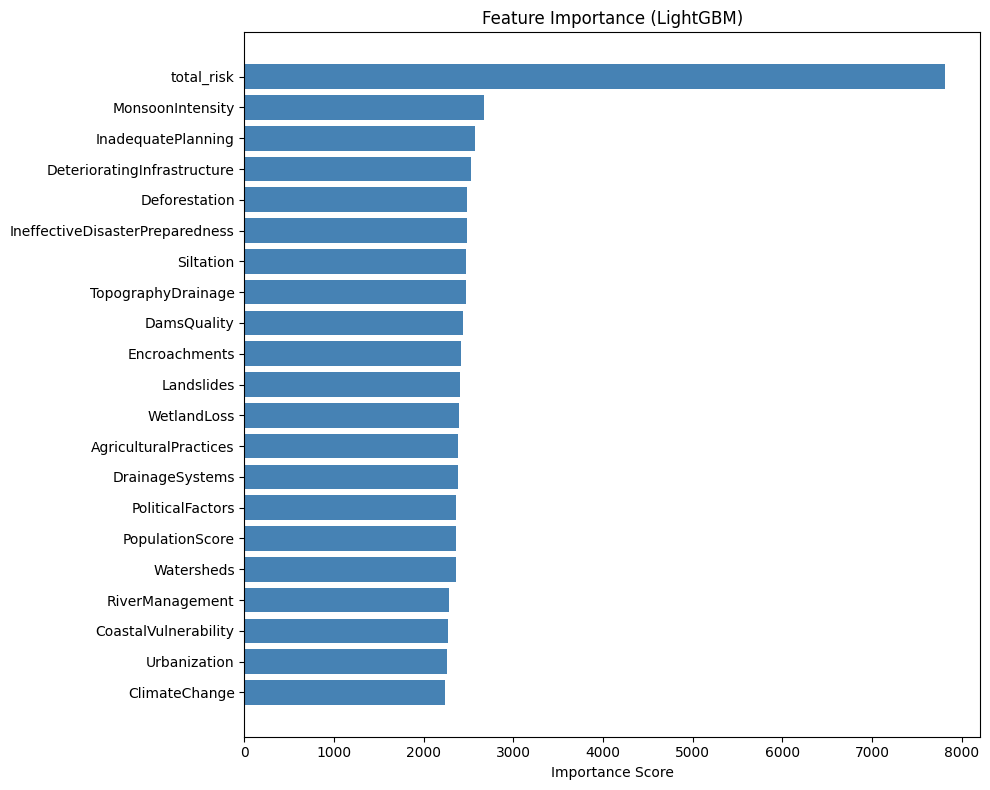

In [14]:
# Feature importance from LightGBM
importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('Feature Importance (LightGBM)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Generate Submission File

In [15]:
# Select best model by highest R2
best_model_name = df_results['R2'].idxmax()
print(f"Best model: {best_model_name} (R2 = {df_results.loc[best_model_name, 'R2']:.6f})")

model_map = {
    'Linear Regression': lr,
    'LightGBM': lgbm,
    'XGBoost': xgb
}
best_model = model_map[best_model_name]

X_test = df_test[all_features]
pred_test = best_model.predict(X_test)

submission = pd.DataFrame({
    'id': df_test['id'],
    'FloodProbability': pred_test
})

submission.to_csv('../data/flood/submission.csv', index=False)
print(f"\nSubmission saved: ../data/flood/submission.csv ({len(submission):,} rows)")
print(submission.head(10))

Best model: LightGBM (R2 = 0.867282)

Submission saved: ../data/flood/submission.csv (745,305 rows)
        id  FloodProbability
0  1117957          0.576189
1  1117958          0.449230
2  1117959          0.452386
3  1117960          0.470222
4  1117961          0.470965
5  1117962          0.507190
6  1117963          0.537752
7  1117964          0.529736
8  1117965          0.471718
9  1117966          0.576154


In [16]:
# Validate submission file
sub_check = pd.read_csv('../data/flood/submission.csv')
print(f"Shape          : {sub_check.shape}")
print(f"Missing values : {sub_check.isnull().sum().sum()}")
print(f"Prediction range: [{sub_check['FloodProbability'].min():.4f}, {sub_check['FloodProbability'].max():.4f}]")
print("\nSample:")
sub_check.head()

Shape          : (745305, 2)
Missing values : 0
Prediction range: [0.3212, 0.7090]

Sample:


,id,FloodProbability
0,1117957,0.576189
1,1117958,0.449230
2,1117959,0.452386
3,1117960,0.470222
4,1117961,0.470965
